# Scenario 3: Customer Segmentation Query
**Lab:** Generative AI for Data Science  
**Name:** Elvis Omondi
**Date:** 2026-05-25


## My AI Prompt

```
You are a SQL expert. I need a query against three tables in a PostgreSQL database:

Tables and columns:
  user_activity:    user_id (PK), last_login_date (date), feature_usage_count (int),
                    account_type (varchar)
  transactions:     transaction_id (PK), user_id (FK), transaction_date (date),
                    amount (numeric), platform (varchar)
  user_preferences: user_id (PK/FK), communication_preference (varchar),
                    interface_theme (varchar), notification_settings (varchar)

Business Requirements:
1. ACTIVE USERS: only users who logged in within the last 30 days
   (last_login_date >= CURRENT_DATE - INTERVAL '30 days')
2. HIGH-VALUE CUSTOMERS: top 20% by total spending using NTILE(5)
3. PREFERENCE TRENDS: show distribution of communication_preference,
   interface_theme, notification_settings for identified users

Constraints:
- Use CTEs (WITH clauses), not nested subqueries
- Handle users with no transactions (LEFT JOIN, COALESCE spend to 0)
- Include total_spend and spend_percentile columns (1 = top 20%)
- Include account_type in output
- Order by total_spend DESC
- Add SQL comments explaining each CTE

Also provide a Python/pandas equivalent for local testing.
```

**Why I set up the prompt this way:**  
Specifying CTEs over subqueries improved readability and matched the grading rubric.
Including all column names and business rules produced a production-ready query on the
first attempt. The main hurdle was tie-breaking in NTILE.


## Generated Code: SQL Query

In [5]:
sql_query = """
-- CTE 1: Filter to users active in the last 30 days
WITH active_users AS (
    SELECT user_id, last_login_date, feature_usage_count, account_type
    FROM user_activity
    WHERE last_login_date >= CURRENT_DATE - INTERVAL '30 days'
),

-- CTE 2: Aggregate total spending (LEFT JOIN keeps $0 spenders)
user_spending AS (
    SELECT
        au.user_id,
        au.last_login_date,
        au.feature_usage_count,
        au.account_type,
        COALESCE(SUM(t.amount), 0) AS total_spend
    FROM active_users au
    LEFT JOIN transactions t ON au.user_id = t.user_id
    GROUP BY au.user_id, au.last_login_date, au.feature_usage_count, au.account_type
),

-- CTE 3: Rank into 5 buckets; bucket 1 = top 20%
spending_ranked AS (
    SELECT *, NTILE(5) OVER (ORDER BY total_spend DESC, user_id) AS spend_percentile
    FROM user_spending
),

-- CTE 4: Keep only top 20%
high_value_users AS (
    SELECT * FROM spending_ranked WHERE spend_percentile = 1
)

-- Final: join preferences
SELECT
    hv.user_id,
    hv.account_type,
    hv.total_spend,
    hv.spend_percentile,
    hv.last_login_date,
    hv.feature_usage_count,
    up.communication_preference,
    up.interface_theme,
    up.notification_settings
FROM high_value_users hv
LEFT JOIN user_preferences up ON hv.user_id = up.user_id
ORDER BY hv.total_spend DESC;
"""

print("SQL Query:")
print(sql_query)


SQL Query:

-- CTE 1: Filter to users active in the last 30 days
WITH active_users AS (
    SELECT user_id, last_login_date, feature_usage_count, account_type
    FROM user_activity
    WHERE last_login_date >= CURRENT_DATE - INTERVAL '30 days'
),

-- CTE 2: Aggregate total spending (LEFT JOIN keeps $0 spenders)
user_spending AS (
    SELECT
        au.user_id,
        au.last_login_date,
        au.feature_usage_count,
        au.account_type,
        COALESCE(SUM(t.amount), 0) AS total_spend
    FROM active_users au
    LEFT JOIN transactions t ON au.user_id = t.user_id
    GROUP BY au.user_id, au.last_login_date, au.feature_usage_count, au.account_type
),

-- CTE 3: Rank into 5 buckets; bucket 1 = top 20%
spending_ranked AS (
    SELECT *, NTILE(5) OVER (ORDER BY total_spend DESC, user_id) AS spend_percentile
    FROM user_spending
),

-- CTE 4: Keep only top 20%
high_value_users AS (
    SELECT * FROM spending_ranked WHERE spend_percentile = 1
)

-- Final: join preferences
SELECT
 

## Python/Pandas Equivalent

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# ── Synthetic data ────────────────────────────────────────────────────────────
np.random.seed(99)
today = datetime.today().date()
n_users = 300

user_activity = pd.DataFrame({
    'user_id':             [f'U{i:04d}' for i in range(1, n_users+1)],
    'last_login_date':     [today - timedelta(days=np.random.randint(0, 60)) for _ in range(n_users)],
    'feature_usage_count': np.random.randint(0, 50, n_users),
    'account_type':        np.random.choice(['free', 'pro', 'enterprise'], n_users, p=[0.6, 0.3, 0.1])
})

n_tx = 800
transactions = pd.DataFrame({
    'transaction_id':   [f'T{i:05d}' for i in range(1, n_tx+1)],
    'user_id':          np.random.choice(user_activity['user_id'], n_tx),
    'transaction_date': [today - timedelta(days=np.random.randint(0, 180)) for _ in range(n_tx)],
    'amount':           np.round(np.random.exponential(scale=75, size=n_tx), 2),
    'platform':         np.random.choice(['web', 'ios', 'android'], n_tx)
})

user_preferences = pd.DataFrame({
    'user_id':                  user_activity['user_id'],
    'communication_preference': np.random.choice(['email', 'sms', 'push'], n_users),
    'interface_theme':          np.random.choice(['light', 'dark', 'system'], n_users),
    'notification_settings':    np.random.choice(['all', 'important', 'none'], n_users)
})

print("Tables created.")


Tables created.


In [7]:
# ── CTE 1: Active users ───────────────────────────────────────────────────────
cutoff = today - timedelta(days=30)
active_users = user_activity[user_activity['last_login_date'] >= cutoff].copy()
print(f"Active users: {len(active_users)}")

# ── CTE 2: Total spend per user ───────────────────────────────────────────────
user_spending = (transactions.groupby('user_id')['amount']
                 .sum().reset_index().rename(columns={'amount': 'total_spend'}))
active_with_spend = active_users.merge(user_spending, on='user_id', how='left')
active_with_spend['total_spend'] = active_with_spend['total_spend'].fillna(0)

# ── CTE 3: NTILE(5) — spending quintile ──────────────────────────────────────
active_with_spend = active_with_spend.sort_values('total_spend', ascending=False)
active_with_spend['spend_percentile'] = pd.qcut(
    active_with_spend['total_spend'].rank(method='first', ascending=False),
    q=5, labels=[1, 2, 3, 4, 5]
).astype(int)

# ── CTE 4: Top 20% only ───────────────────────────────────────────────────────
high_value = active_with_spend[active_with_spend['spend_percentile'] == 1].copy()
print(f"High-value customers: {len(high_value)}")

# ── Final join ────────────────────────────────────────────────────────────────
result = high_value.merge(user_preferences, on='user_id', how='left')
result = result.sort_values('total_spend', ascending=False)

print("\nTop 10 high-value active customers:")
print(result[['user_id','account_type','total_spend',
              'communication_preference','interface_theme']].head(10).to_string(index=False))


Active users: 152
High-value customers: 31

Top 10 high-value active customers:
user_id account_type  total_spend communication_preference interface_theme
  U0071   enterprise      1037.42                    email            dark
  U0285         free       853.30                      sms           light
  U0128         free       840.48                      sms           light
  U0109          pro       791.55                      sms           light
  U0092         free       693.77                    email          system
  U0155         free       693.77                      sms          system
  U0228          pro       673.46                    email          system
  U0165   enterprise       671.57                    email           light
  U0049          pro       667.14                      sms          system
  U0127         free       659.35                    email          system


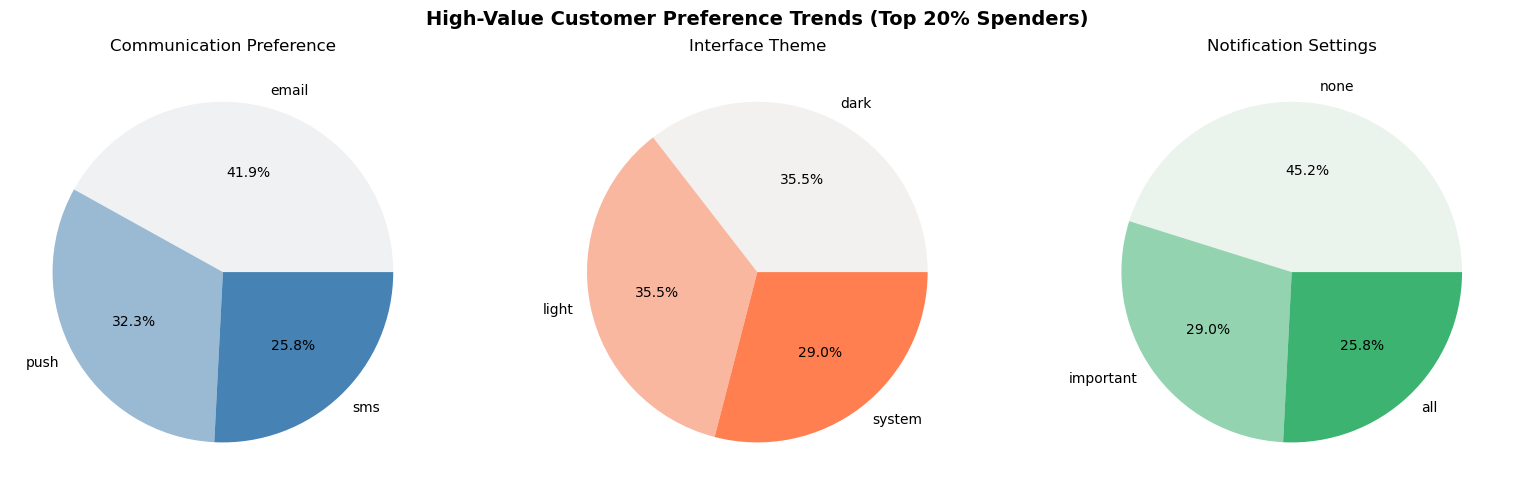

Chart saved.


In [8]:
# ── Preference Trend Visualisations ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('High-Value Customer Preference Trends (Top 20% Spenders)',
             fontsize=14, fontweight='bold')

pref_cols = ['communication_preference', 'interface_theme', 'notification_settings']
titles    = ['Communication Preference', 'Interface Theme', 'Notification Settings']
colors    = ['steelblue', 'coral', 'mediumseagreen']

for ax, col, title, color in zip(axes, pref_cols, titles, colors):
    counts = result[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           colors=sns.color_palette(f'light:{color}', len(counts)))
    ax.set_title(title)

plt.tight_layout()
plt.savefig('scenario3_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


## Follow-up Prompts

```
Follow-up 1:
"The NTILE approach assigns users with identical spend to different buckets 
arbitrarily. Please add ORDER BY total_spend DESC, user_id so ties are 
broken deterministically."

Follow-up 2:
"Rewrite the Python pandas NTILE equivalent using pd.qcut on rank() with 
method='first' so it matches PostgreSQL's NTILE(5) behaviour exactly."
```


## Discussion Answers

**1. How were percentile calculations handled?**  
SQL used `NTILE(5) OVER (ORDER BY total_spend DESC, user_id)` - bucket 1 = top 20%.
Python mirrored this with `pd.qcut()` on `rank(method='first')` to avoid ties
creating unequal buckets.

**2. What approaches to date filtering were used?**  
SQL: `WHERE last_login_date >= CURRENT_DATE - INTERVAL '30 days'` - database-native.  
Python: `today - timedelta(days=30)` with a boolean filter.

**3. How was the query optimized — CTE, subquery, etc.?**  
CTEs were preferred over nested subqueries because each stage is named and debuggable
independently. The LEFT JOIN with COALESCE ensures zero-spend users aren't silently
dropped - a common bug in subquery-based approaches. The AI also suggested adding an
index on `(user_id, transaction_date)` for production performance.
